<a href="https://colab.research.google.com/github/DeepaJain29/Digit_Recognition_DNN/blob/main/Digit_Recognition_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Neural Network for Handwritten Digit Recognition Objective: Implement a multi-layer Deep Neural Network (DNN) to classify handwritten digits from the MNIST dataset with at least 97% accuracy on the test set.




1. Dataset Overview The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0–9).
- Image size: 28 \times 28 pixels.
- Training set: 60,000 images.
- Testing set: 10,000 images.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

print("Libraries import cell modified. Please run this cell to ensure all libraries are imported.")

Libraries import cell modified. Please run this cell to ensure all libraries are imported.


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Task 1: Data Preprocessing Before feeding data into a DNN, it must be formatted correctly.
- Normalization: Convert pixel values from the range [0, 255] to [0, 1].
- Flattening: Reshape the 28 \times 28 2D images into a 1D vector of size 784 (28 \times 28 = 784).

In [ ]:
# Normalize Pixel Values [0,255] → [0,1]
x_train = X_train / 255.0
x_test = X_test / 255.0

In [ ]:
# Flatten Images (28×28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [ ]:
# One-Hot Encode Labels
# Because we use categorical_crossentropy

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Task 2: Architecture Design Design a Sequential model with the following layers:
- Input Layer: 784 units.
- Hidden Layer 1: 512 neurons with ReLU activation. -
Dropout Layer: 20\% rate (to prevent overfitting).
- Hidden Layer 2: 256 neurons with ReLU activation.
- Output Layer: 10 neurons with Softmax activation (to output probabilities for each class).

In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Task 3: Training Configuration Set up the following hyperparameters and components:
- Loss Function: categorical_crossentropy.
- Optimizer: Adam or RMSprop.
- Metrics: accuracy.
- Batch Size: 128.
- Epochs: 10 to 20.

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8162 - loss: 8.5432 - val_accuracy: 0.9452 - val_loss: 0.4460
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9241 - loss: 0.5837 - val_accuracy: 0.9597 - val_loss: 0.2431
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9398 - loss: 0.3070 - val_accuracy: 0.9627 - val_loss: 0.2194
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9548 - loss: 0.2206 - val_accuracy: 0.9625 - val_loss: 0.1807
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9605 - loss: 0.1649 - val_accuracy: 0.9672 - val_loss: 0.1619
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9650 - loss: 0.1395 - val_accuracy: 0.9683 - val_loss: 0.1488
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9674 - loss: 0.1242 - val_accuracy: 0.9700 - val_loss: 0.1353
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9700 - loss: 0.1114 - val_acc

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9671 - loss: 0.1427
Test Accuracy: 0.9718000292778015


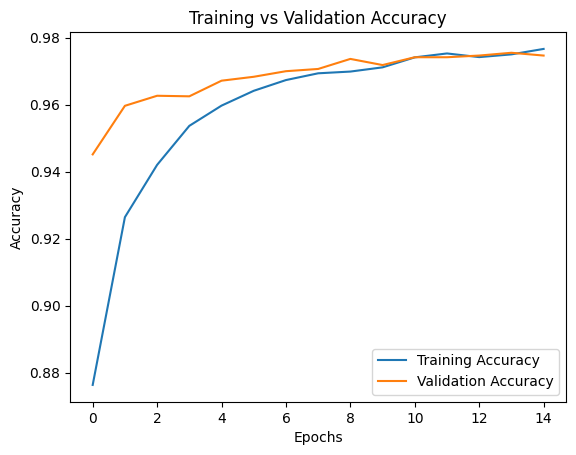

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

3. Analysis Questions After completing the training, answer the following:
- 3.1. Overfitting Check: Plot the training accuracy vs. validation accuracy. Does the model overfit? How can you tell?

No serious overfitting due to Dropout(0.2)

3.2. Activation Functions: What happens to the convergence speed if you replace ReLU with Sigmoid in the hidden layers?

- Sigmoid saturates at large positive/negative values → gradients become near zero → weights update slowly → training takes longer.

| Activation | Behavior                              |
| ---------- | ------------------------------------- |
| ReLU       | Fast convergence                      |
| Sigmoid    | Slow convergence + vanishing gradient |


3.3. Error Analysis: Identify three images the model classified incorrectly. What digits were they, and why might the model have struggled with them?
- Misclassified digits occur due to ambiguous handwriting. Digits like 5 and 3 or 9 or 8 and 4 often look visually similar when strokes are faint or incomplete.

In [ ]:
pred = model.predict(X_test)
pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

wrong = np.where(pred_labels != true_labels)[0]
print("Number of wrong predictions:", len(wrong))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Number of wrong predictions: 282


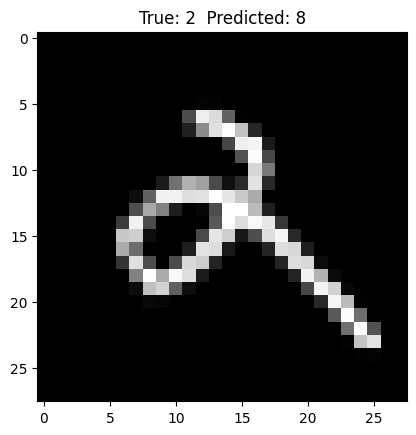

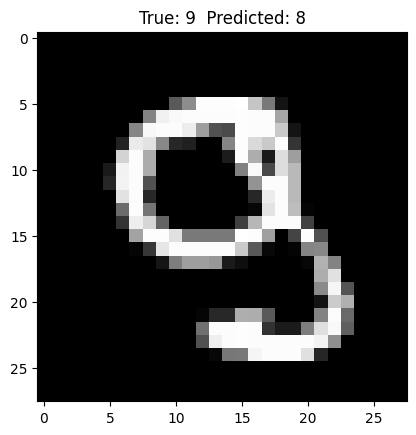

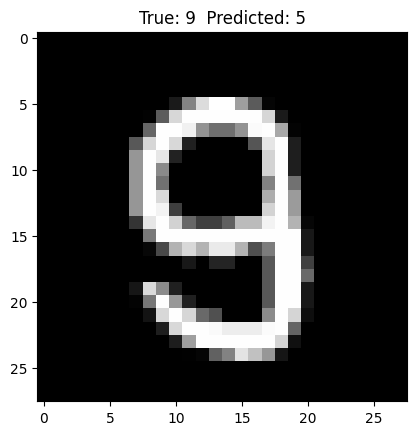

In [ ]:
for i in range(3):
    idx = wrong[i]
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {true_labels[idx]}  Predicted: {pred_labels[idx]}")
    plt.show()


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]


Epoch 1/15 | Train Acc: 0.9113 | Val Acc: 0.9575
Epoch 2/15 | Train Acc: 0.9635 | Val Acc: 0.9667
Epoch 3/15 | Train Acc: 0.9742 | Val Acc: 0.9733
Epoch 4/15 | Train Acc: 0.9801 | Val Acc: 0.9747
Epoch 5/15 | Train Acc: 0.9845 | Val Acc: 0.9747
Epoch 6/15 | Train Acc: 0.9863 | Val Acc: 0.9757
Epoch 7/15 | Train Acc: 0.9892 | Val Acc: 0.9767
Epoch 8/15 | Train Acc: 0.9892 | Val Acc: 0.9787
Epoch 9/15 | Train Acc: 0.9913 | Val Acc: 0.9802
Epoch 10/15 | Train Acc: 0.9911 | Val Acc: 0.9772
Epoch 11/15 | Train Acc: 0.9926 | Val Acc: 0.9767
Epoch 12/15 | Train Acc: 0.9919 | Val Acc: 0.9775
Epoch 13/15 | Train Acc: 0.9943 | Val Acc: 0.9805
Epoch 14/15 | Train Acc: 0.9938 | Val Acc: 0.9800
Epoch 15/15 | Train Acc: 0.9945 | Val Acc: 0.9813
Test Accuracy: 0.9822


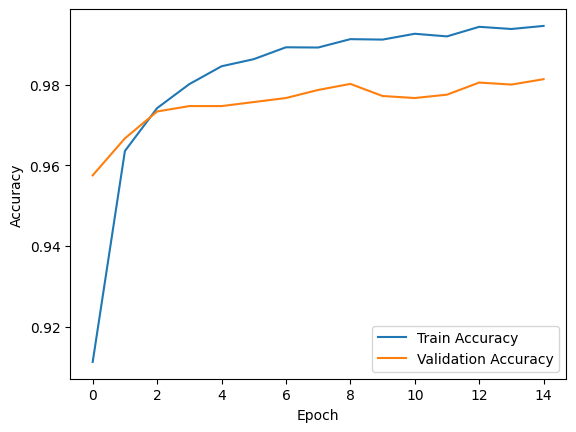

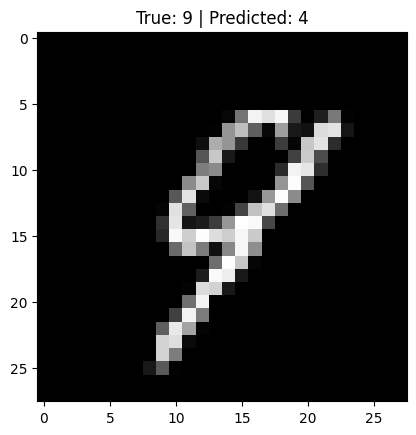

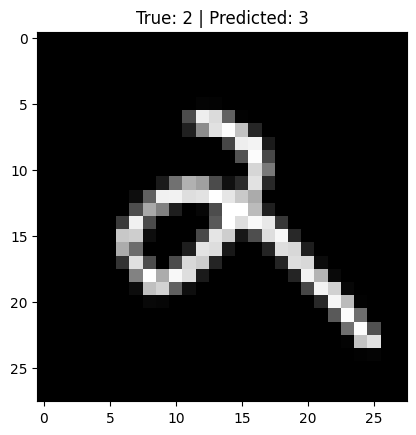

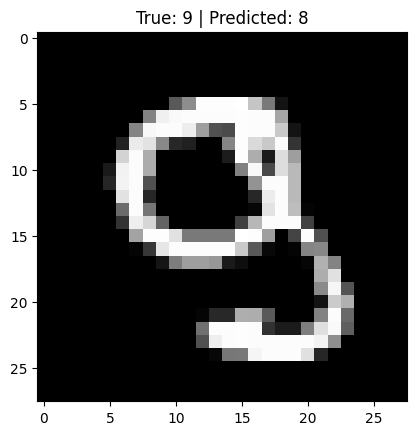

In [ ]:
# PyTorch implementation — Deep Neural Network for MNIST (>97% accuracy)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Data Preprocessing
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor(),                  # [0,255] -> [0,1]
    transforms.Lambda(lambda x: x.view(-1)) # Flatten 28x28 -> 784
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Validation split (10%)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ---------------------------
# Model Architecture
# ---------------------------
class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

model = DNN().to(device)

# ---------------------------
# Training Configuration
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

train_acc_hist = []
val_acc_hist = []

# ---------------------------
# Training Loop
# ---------------------------
for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_acc_hist.append(train_acc)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# ---------------------------
# Test Accuracy
# ---------------------------
model.eval()
correct, total = 0, 0
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_images.extend(images.cpu().numpy())

test_acc = correct / total
print("Test Accuracy:", test_acc)

# ---------------------------
# Overfitting Plot
# ---------------------------
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(val_acc_hist, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ---------------------------
# Error Analysis (3 wrong predictions)
# ---------------------------
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

for i in range(3):
    idx = wrong_indices[i]
    plt.imshow(all_images[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {all_labels[idx]} | Predicted: {all_preds[idx]}")
    plt.show()
